# Reconstruct the Stanford Bunny

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
from tqdm.notebook import trange
import k3d
import sys
import os
import time
import copy
import trimesh
import mesh_to_sdf
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from models.model_architecture import PlaceholderNet, GeneralNet
from training.optimizers import GaussNewton, GaussNewtonWoodburyBig
from util.surface_sampling import sample_model_surface_binsearch, sample_model_surface_newton 
from util.error_metrics import chamfer_div, compute_distance 
from util.visualization.utils_mesh import get_mesh

torch.manual_seed(0)


device = 'cuda' #if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

In [37]:
mesh = trimesh.load("bun_zipper_res3.ply")
pts = 9*torch.tensor(mesh.vertices, dtype=torch.float64) + torch.tensor([0.1, -1, 0], dtype=torch.float64)
fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(mesh.vertices, mesh.faces, color=0xbbbbbb, side='double', flat_shading=False)

fig.display()

Output()

In [38]:
"""Load the model"""
# model = PlaceholderNet(ks=[3, 128, 128, 128, 1], act=torch.sin)
# model.load_state_dict(torch.load('3,128,128,128,1,sin,bunny'))
model_true = PlaceholderNet(ks=[3, 32, 32, 32, 1], act=torch.sin)
model_true.load_state_dict(torch.load('3,32,32,32,1,sin,bunny'))
model_true.double()
pts = sample_model_surface_newton(model_true, pts)


In [39]:
"""Plot the initial model"""
verts, faces = get_mesh(
    model_true.float(), N=128, device=device,
    bbox_min=torch.tensor([-1, -1, -1], dtype=torch.float64),
    bbox_max=torch.tensor([1, 1, 1], dtype=torch.float64),
    chunks=2
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
fig += k3d.points(pts.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()
model_true.double()

Output()

PlaceholderNet(
  (fcs): ModuleList(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=True)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [40]:
with torch.no_grad():
    true_mean_curvatures = model_true.r_mean_curvature(model_true.params, pts, torch.zeros(pts.shape[0], dtype=torch.float64))

## Pretraining

In [53]:
model = PlaceholderNet(ks=[3, 32, 32, 32, 1], act=torch.sin)
model = model.double()

# Generate random training points
num_pretrain_samples = 10000
bounds = torch.tensor([[-1.5, 1.5], [-1.5, 1.5], [-1.5, 1.5]], dtype=torch.float64)
pts_pretrain = torch.rand(num_pretrain_samples, 3, dtype=torch.float64) * (bounds[:,1] - bounds[:,0]) + bounds[:,0]

# SDF of a unit ball
def pretrain_loss(model, params, pts):
    inputs = pts.to(dtype=torch.float64)
    targets = inputs.norm(dim=1) - 1  # SDF of unit ball
    preds = model(inputs).squeeze(1)
    return 0.5 * (preds - targets).square().mean()

# Pretraining loop
pretrain_optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_pretrain_iters = 1000

for i in range(num_pretrain_iters):
    pretrain_optimizer.zero_grad()
    loss = pretrain_loss(model, model.params, pts_pretrain)
    loss.backward()
    pretrain_optimizer.step()
    
    if i % 100 == 0:
        print(f"Pretrain Iter {i}: Loss = {loss.item():.6f}")

print("Pretraining completed!")


Pretrain Iter 0: Loss = 0.244954
Pretrain Iter 100: Loss = 0.090433
Pretrain Iter 200: Loss = 0.061827
Pretrain Iter 300: Loss = 0.001954
Pretrain Iter 400: Loss = 0.000843
Pretrain Iter 500: Loss = 0.000534
Pretrain Iter 600: Loss = 0.000387
Pretrain Iter 700: Loss = 0.000337
Pretrain Iter 800: Loss = 0.000316
Pretrain Iter 900: Loss = 0.000302
Pretraining completed!


In [54]:
# Gauss-Newton weights:
loss_weights = {"interface": 1.0, "eikonal": 0.001, "mean_curvature": 0.0}
# loss_weights = {"interface": 1.0, "eikonal": 0.1, "mean_curvature": 0.0}


pts_eikonal = 2 * torch.rand([1000, 3], dtype=torch.float64) - 1
# pts_surface = sample_model_surface_binsearch(model, torch.rand([0, 3], dtype=torch.float64), bound_limit=1)
pts_surface = pts

config = {
    "pts_boundary": pts,
    "pts_eikonal": pts_eikonal,
    "pts_surface": pts_surface,
    "vals_mean_curvature": true_mean_curvatures,
    "loss_weights": loss_weights,
    "regularization": 1e-7,
}

# model = PlaceholderNet(ks=[3, 32, 32, 32, 1], act=torch.sin)
# model.double()

  0%|          | 0/1000 [00:00<?, ?it/s]

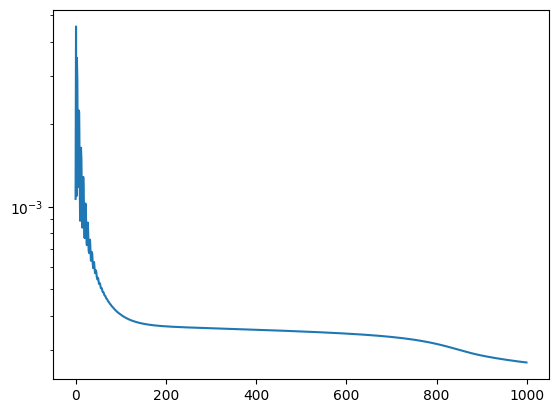

In [56]:
model = model.double()
params = model.params
loss_over_iters = {}
# Gauss-Newton:
# optimizer = GaussNewtonWoodburyBig(model, lr=1e-1, config=config)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
for i in (pbar:=trange(1000)):
    optimizer.zero_grad()

    # if i == 201:
    #     loss_weights = {"interface": 1.0, "eikonal": 0.001, "mean_curvature": 1.0}
    #     config["loss_weights"] = loss_weights
    #     config["regularization"] = 1e-4
    #     optim.config = config
        

    loss_interface  = 0.5*model.f(params, pts).square().mean()
    loss_eikonal  = 0.5*model.r_eikonal(params, pts_eikonal).squeeze(1).square().mean()
    loss_mean_curvature = 0.5*model.r_mean_curvature(params, pts_surface, true_mean_curvatures).squeeze(1).square().mean()
    loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["mean_curvature"] * loss_mean_curvature
    loss.backward()
    with torch.no_grad():
        loss_over_iters[i] = loss.item()
        pbar.set_description(f"Interface: {loss_interface.item():.2e} "
                             f"Eikonal: {loss_eikonal.item():.2e} "
                             f"Mean Curvature: {loss_mean_curvature.item():.2e} "
                             f"{len(pts_surface)}")
    optimizer.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

In [ ]:
model = model.double()
params = model.params
loss_over_iters = {}
# Gauss-Newton:
optimizer = GaussNewton(model, lr=1e-2, config=config)
# Adam:
# optim = torch.optim.Adam(model.parameters(), lr=1e-3)
for i in (pbar:=trange(1000)):
    optimizer.zero_grad()

    loss_interface  = 0.5*model.f(params, pts_surface_original).square().mean()
    loss_eikonal  = 0.5*model.r_eikonal(params, pts_eikonal).squeeze(1).square().mean()

    # pts_surface = sample_model_surface_binsearch(model, torch.rand([0, 3], dtype=torch.float64), bound_limit=1)
    pts_surface = sample_model_surface_newton(model, pts_eikonal) 
    config["pts_surface"] = pts_surface
    optimizer.config = config
    loss_mean_curvature = 0.5*model.r_mean_curvature(params, pts_surface).squeeze(1).square().mean()
    loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["mean_curvature"] * loss_mean_curvature
    loss.backward()
    with torch.no_grad():
        loss_over_iters[i] = loss.item()
        pbar.set_description(f"Interface: {loss_interface.item():.2e} "
                             f"Eikonal: {loss_eikonal.item():.2e} "
                             f"Mean Curvature: {loss_mean_curvature.item():.2e} "
                             f"{len(pts_surface)}")
    optimizer.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

In [57]:
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-1, -1, -1], dtype=torch.float64),
    bbox_max=torch.tensor([1, 1, 1], dtype=torch.float64),
    chunks=2
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
# fig += k3d.points(pts_surface.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()
model.double()

Output()

PlaceholderNet(
  (fcs): ModuleList(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=True)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [ ]:
model = model.double()
params = model.params
loss_over_iters = {}
# Gauss-Newton:
optimizer = GaussNewton(model, lr=1e-2, config=config)
# Adam:
# optim = torch.optim.Adam(model.parameters(), lr=1e-3)
for i in (pbar:=trange(1000)):
    optimizer.zero_grad()

    loss_interface  = 0.5*model.f(params, pts_surface_original).square().mean()
    loss_eikonal  = 0.5*model.r_eikonal(params, pts_eikonal).squeeze(1).square().mean()

    # pts_surface = sample_model_surface_binsearch(model, torch.rand([0, 3], dtype=torch.float64), bound_limit=1)
    pts_surface = sample_model_surface_newton(model, pts_eikonal) 
    config["pts_surface"] = pts_surface
    optimizer.config = config
    loss_mean_curvature = 0.5*model.r_mean_curvature(params, pts_surface).squeeze(1).square().mean()
    loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["mean_curvature"] * loss_mean_curvature
    loss.backward()
    with torch.no_grad():
        loss_over_iters[i] = loss.item()
        pbar.set_description(f"Interface: {loss_interface.item():.2e} "
                             f"Eikonal: {loss_eikonal.item():.2e} "
                             f"Mean Curvature: {loss_mean_curvature.item():.2e} "
                             f"{len(pts_surface)}")
    optimizer.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

In [94]:
verts, faces = get_mesh(
    model.eval().float(), N=128, device=device,
    bbox_min=torch.tensor([-1, -1, -1], dtype=torch.float64),
    bbox_max=torch.tensor([1, 1, 1], dtype=torch.float64),
    chunks=2
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
fig += k3d.points(pts_surface.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()
model.double()

Output()

PlaceholderNet(
  (fcs): ModuleList(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=True)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [5]:
# Gauss-Newton weights:
loss_weights = {"interface": 1.0, "mean_curvature": 1.0}

pts_surface = sample_model_surface_binsearch(model, torch.rand([0, 3], dtype=torch.float64), bound_limit=1)
# pts_surface_original = pts_surface
# pts_eikonal = 2 * torch.rand([500, 3], dtype=torch.float64) - 1

config = {
    "pts_boundary": pts_surface_original,
    # "pts_eikonal": pts_eikonal,
    "pts_surface": pts_surface,
    "loss_weights": loss_weights,
    "regularization": 1e-6,
}

  0%|          | 0/5 [00:00<?, ?it/s]

/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/torch/autograd/graph.py:744: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


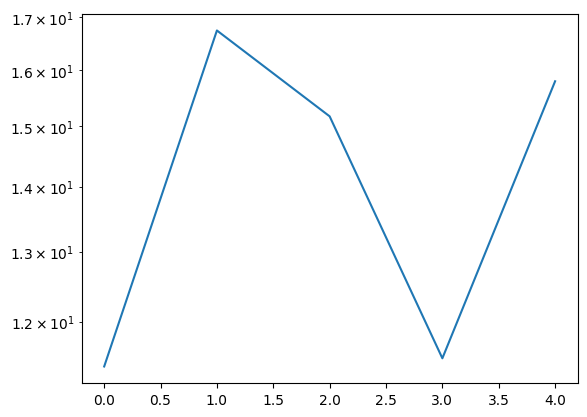

In [6]:
model = model.double()
params = model.params
loss_over_iters = {}
# Gauss-Newton:
optimizer = GaussNewtonWoodburyBig(model, lr=1e-1, config=config)
# Adam:
# optim = torch.optim.Adam(model.parameters(), lr=1e-3)
for i in (pbar:=trange(5)):
    optimizer.zero_grad()
    
    with torch.no_grad():
    
        pts_surface = sample_model_surface_binsearch(model, torch.rand([0, 3], dtype=torch.float64), bound_limit=1)
        pts_surface = sample_model_surface_newton(model, pts_surface) 
        config["pts_surface"] = pts_surface
        optimizer.config = config
        
        loss_mean_curvature = 0.5*model.r_mean_curvature(params, pts_surface).squeeze(1).square().mean()
        loss = loss_weights["mean_curvature"] * loss_mean_curvature
        loss_over_iters[i] = loss.item()
        pbar.set_description(f"Mean Curvature: {loss_mean_curvature.item():.2e} "
                             f"{len(pts_surface)}")
    optimizer.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

In [7]:
verts, faces = get_mesh(
    model.eval().float(), N=128, device=device,
    bbox_min=torch.tensor([-1, -1, -1], dtype=torch.float64),
    bbox_max=torch.tensor([1, 1, 1], dtype=torch.float64),
    chunks=2
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
fig += k3d.points(pts_surface.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()
model.double()

Output()

PlaceholderNet(
  (fcs): ModuleList(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1-2): 2 x Linear(in_features=128, out_features=128, bias=True)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)